# Metodología de preprocesamiento

1. Visualizar al atributo a preprocesar 
2. Inferir la estrategia de preprocesamiento. 
3. Justificar la estrategia de preprocesamiento desde referentes teóricos. 

# Preprocesameinto de la variable objetivo 

Aplicar una transformación logarítmica a tu variable `casos_dengue` no solo es adecuado, sino que en este caso es **altamente recomendable**.


In [1]:
import pandas as pd 
path_marco = r"C:\Users\marco\OneDrive - Universidad de Antioquia\Documentos\2_recursos_ensenanza\5_arima\6_datos_arima\4_base_datos_consolidada\datos_fusionados_y_rezagados.xlsx"
path_janis = ""
df_epi_meteo_rezagos = pd.read_excel(path_marco) 
df_epi_meteo_rezagos.head()

,año,semana_epidemiologica,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,...,uv_lag_3,uv_lag_4,uv_lag_5,uv_lag_6,uv_lag_7,uv_lag_8,uv_lag_9,uv_lag_10,uv_lag_11,uv_lag_12
0,2021,1,28.252857,34.200000,23.832857,16.308571,70.508571,5.72,1,0.121429,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021,2,28.687143,34.910000,24.195714,17.318571,72.885714,19.15,5,0.117143,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021,3,29.592857,36.372857,24.090000,16.112857,65.122857,0.77,0,0.124286,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021,4,29.190000,35.978571,24.200000,16.511429,68.068571,12.92,4,0.122857,...,2.222857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021,5,29.454286,35.882857,24.684286,17.427143,70.105714,17.94,3,0.120000,...,2.254286,2.222857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df_epi_meteo_rezagos.columns 

Index(['año', 'semana_epidemiologica', 'temp', 'temp_max', 'temp_min',
       'hum_esp', 'hum_rel', 'prec', 'dias_lluvia', 'vel_vi',
       ...
       'uv_lag_3', 'uv_lag_4', 'uv_lag_5', 'uv_lag_6', 'uv_lag_7', 'uv_lag_8',
       'uv_lag_9', 'uv_lag_10', 'uv_lag_11', 'uv_lag_12'],
      dtype='str', length=146)

In [11]:
df_epi_meteo_rezagos['casos_dengue'] 

0      0
1      0
2      1
3      0
4      0
      ..
256    8
257    9
258    7
259    5
260    9
Name: casos_dengue, Length: 261, dtype: int64

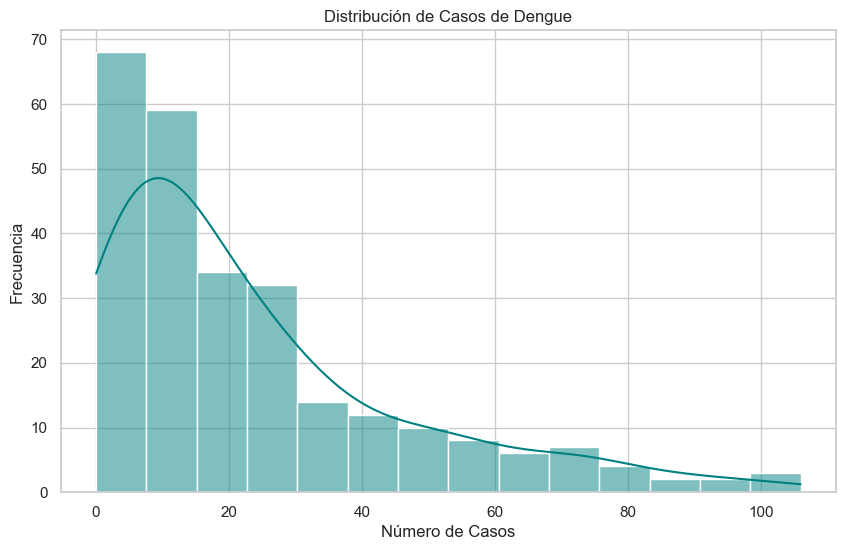

In [3]:
# Graficar el histograma de la variables casos_dengue 

import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo visual
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(df_epi_meteo_rezagos['casos_dengue'], kde=True, color='teal')

plt.title('Distribución de Casos de Dengue')
plt.xlabel('Número de Casos')
plt.ylabel('Frecuencia')
plt.savefig(r"C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\2_consolidacion_datos_meteoro_epidemiologicos_reales\05_preprocesamiento\images\1_histograma_casos_dengue.png")  # Guardar la figura 
plt.show()

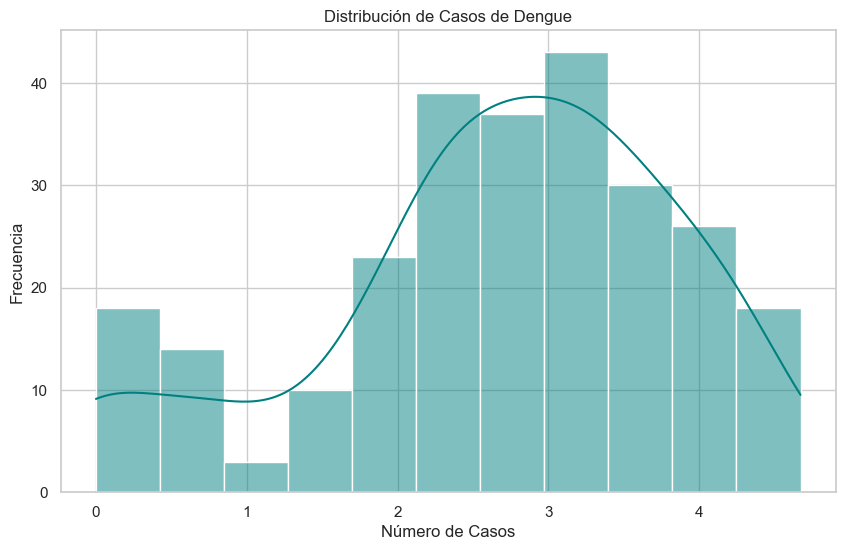

In [6]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo visual
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(np.log(1 + df_epi_meteo_rezagos['casos_dengue']), kde=True, color='teal')

plt.title('Distribución de Casos de Dengue')
plt.xlabel('Número de Casos')
plt.ylabel('Frecuencia')
plt.savefig(r"C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\2_consolidacion_datos_meteoro_epidemiologicos_reales\05_preprocesamiento\images\2_histograma_casos_dengue_aplicado_ln.png")  # Guardar la figura 
plt.show()

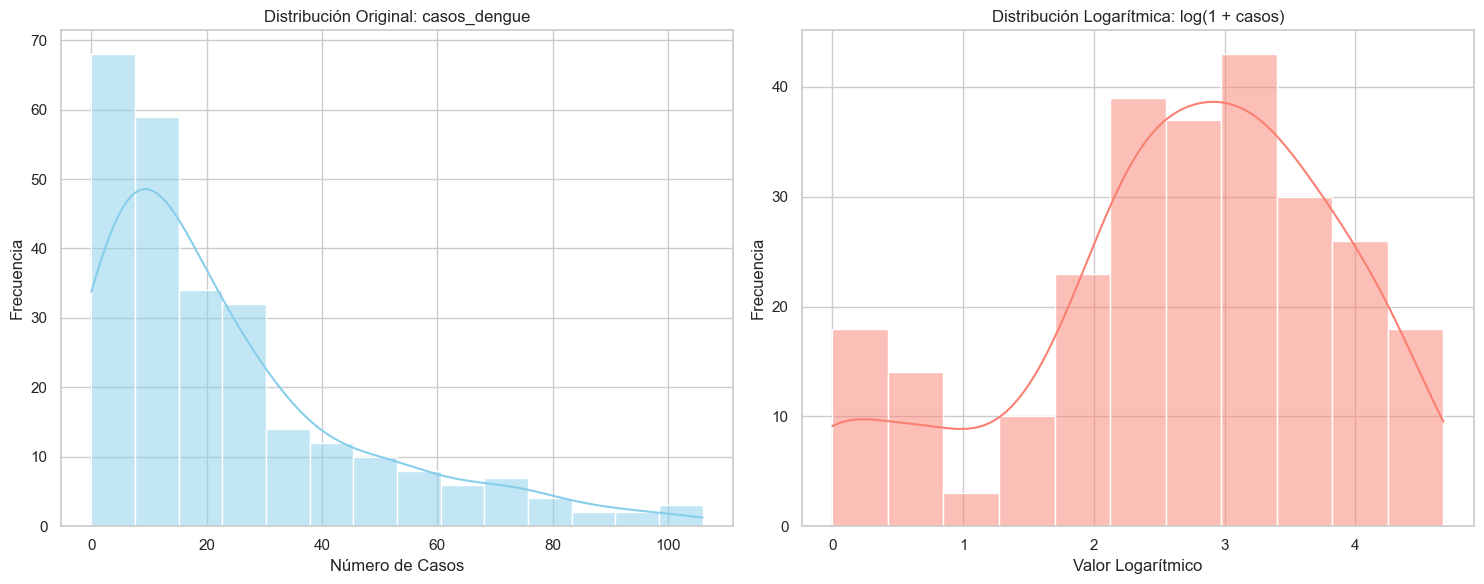

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurar el estilo
sns.set_theme(style="whitegrid")

# Crear una figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Histograma Original (Izquierda)
sns.histplot(df_epi_meteo_rezagos['casos_dengue'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribución Original: casos_dengue')
axes[0].set_xlabel('Número de Casos')
axes[0].set_ylabel('Frecuencia')

# 2. Histograma con Transformación Logarítmica (Derecha)
# Usamos np.log1p para evitar errores con valores en 0
casos_log = np.log1p(df_epi_meteo_rezagos['casos_dengue'])
sns.histplot(casos_log, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Distribución Logarítmica: log(1 + casos)')
axes[1].set_xlabel('Valor Logarítmico')
axes[1].set_ylabel('Frecuencia')

# Ajustar el espacio entre gráficas
plt.tight_layout()
plt.savefig(r"C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\2_consolidacion_datos_meteoro_epidemiologicos_reales\05_preprocesamiento\images\3_comparacion_histogramas_variable_objetivo.png")  # Guardar la figura
plt.show()


Aquí tienes el análisis detallado basado en el histograma y los modelos de series temporales que planeas usar:



### 1. ¿Por qué es adecuado aplicar el logaritmo?

El histograma muestra una **asimetría positiva severa** (sesgo a la derecha o *right-skewed*). La gran mayoría de los datos se concentran en valores bajos (cercanos a 0-20), pero tienes una "cola" larga que llega hasta más de 100.



* **Estabilización de la varianza:** En datos de epidemiología (como el dengue), la varianza suele crecer proporcionalmente a la media (a más casos, más fluctuación). El logaritmo ayuda a que la varianza sea constante (**homocedasticidad**), un requisito clave para modelos lineales como ARIMA.


* **Normalización:** Los modelos ARIMA/SARIMA asumen que los residuos del modelo siguen una distribución normal. Al aplicar logaritmo, "comprimes" los valores altos y "expandes" los bajos, haciendo que la distribución se acerque más a una campana de Gauss.


* **Linealización de relaciones:** El dengue suele crecer de forma exponencial durante brotes. El logaritmo convierte ese crecimiento exponencial en uno lineal, que es mucho más fácil de capturar para un modelo ARIMAX.




### 2. Justificación: ¿Es aplicable no hacer preprocesamiento?

Si decides **no** aplicar preprocesamiento (dejar la variable en su escala original), te enfrentarás a varios problemas técnicos que probablemente degraden el rendimiento de tus modelos:

* **Sensibilidad a valores extremos:** Sin preprocesamiento, los picos de casos (outliers visuales en la cola derecha) tendrán un peso desproporcionado en el cálculo del error (MSE). El modelo intentará "perseguir" esos picos y perderá precisión en los periodos normales.
* **Predicciones negativas:** Si no transformas los datos y el modelo detecta una tendencia bajista fuerte cerca de cero, ARIMA podría predecir valores negativos de casos, lo cual es físicamente imposible. Al usar $\log(y)$, la predicción revertida $\exp(\hat{y})$ siempre será positiva.
* **Falta de convergencia:** En SARIMAX, si la estacionalidad es **multiplicativa** (el tamaño de los picos estacionales varía con el nivel de la serie), los modelos ARIMA (que son aditivos por naturaleza) fallarán estrepitosamente a menos que uses el logaritmo para convertir esa relación en aditiva.

---



### 3. Consideraciones para ARIMA, ARIMAX y SARIMAX

Al trabajar con estos modelos específicos, ten en cuenta lo siguiente:

1.  **Manejo de ceros:** Si tienes semanas con **0 casos**, el $\log(0)$ es indefinido. Debes aplicar una transformación $\log(y + 1)$.
2.  **Diferenciación ($d, D$):** Es muy probable que después del logaritmo sigas necesitando diferenciar la serie para hacerla estacionaria. El logaritmo estabiliza la varianza, pero la diferenciación estabiliza la media.
3.  **Variables Exógenas (ARIMAX):** Si usas variables como temperatura o precipitación, asegúrate de evaluar si estas también necesitan transformación. La relación entre "Temperatura" y "$\log(\text{Casos})$" suele ser mucho más robusta estadísticamente.
4.  **Interpretación:** Recuerda que al terminar, deberás aplicar la función inversa ($\exp$) a tus predicciones para volver a la escala original de "número de personas".

**En conclusión:** No preprocesar esta variable sería un error metodológico dado el sesgo visible. La transformación logarítmica es el estándar de oro para este tipo de distribuciones en modelos de series de tiempo.

# Referentes que justifican este preprocesamiento  

Para sustentar tu decisión académica o investigativa, puedes apoyarte en estos 5 referentes y pilares técnicos que validan la transformación logarítmica en modelos de conteo epidemiológico y series temporales:

### 1. Box & Cox (La Transformación de Box-Cox)
George Box y David Cox son los referentes primordiales. Su metodología demuestra que para variables que no son normales y tienen varianza no constante, una transformación de potencia (donde el logaritmo es el caso más común) es esencial para que los modelos lineales sean válidos.
* **Argumento:** Sin esta transformación, violas los supuestos de **homocedasticidad** necesarios para que los estimadores de tu ARIMA sean eficientes.

### 2. Rob J. Hyndman (*Forecasting: Principles and Practice*)
Es probablemente el autor más influyente hoy en día en series de tiempo. En su libro de referencia, explica que si la variación estacional de una serie parece crecer con el nivel de la serie (como ocurre en los brotes de dengue), se debe usar una transformación logarítmica para convertir la **estacionalidad multiplicativa en aditiva**.
* **Argumento:** Los modelos SARIMA estándar son aditivos; el logaritmo es la herramienta para que el modelo "entienda" crecimientos exponenciales.



### 3. Organización Panamericana de la Salud (OPS) - Guías de Vigilancia
En sus manuales técnicos para el análisis de brotes, la OPS recomienda frecuentemente el uso de tasas o transformaciones logarítmicas al graficar y modelar curvas epidémicas para estabilizar la visualización de la tendencia frente a los picos súbitos de casos.
* **Argumento:** El logaritmo ayuda a comparar la tasa de crecimiento entre diferentes periodos, independientemente de la magnitud absoluta del brote.

### 4. Robert Shumway y David Stoffer (*Time Series Analysis and Its Applications*)
Referentes académicos clásicos. Explican que para datos de conteo (como el número de enfermos), la distribución suele seguir una **Poisson** o una **Binomial Negativa**, donde la varianza aumenta con la media.
* **Argumento:** El logaritmo actúa como una "función de enlace" que permite tratar estos datos de conteo dentro del marco de los modelos gaussianos (como ARIMA).

### 5. Estudios de Caso en *The Lancet* o *Nature* (Modelado de Dengue)
Si buscas literatura específica, autores como **Moritz Kraemer** o **Simon Hay**, expertos en mapeo de enfermedades infecciosas, suelen preprocesar los datos de incidencia mediante $\log(n + 1)$ para manejar la sobredispersión de los datos de dengue en climas tropicales.
* **Argumento:** En el mundo real, los datos de dengue tienen muchos "ceros" y "picos". El preprocesamiento no es opcional, es el estándar para evitar que el ruido de los picos domine la señal del modelo.

---

### Resumen para tu investigación:
| Referente | Concepto Clave | Aplicación en tu caso |
| :--- | :--- | :--- |
| **Box-Cox** | Estabilización de varianza | Corregir el sesgo que ves en tu histograma. |
| **Hyndman** | Estacionalidad aditiva | Hacer que SARIMAX funcione correctamente. |
| **OPS** | Curvas Epidémicas | Normalizar la visualización de brotes. |
| **Shumway & Stoffer** | Linealización | Permitir que ARIMAX use regresores externos de forma lineal. |
| **Kraemer / Hay** | $\log(n+1)$ | Manejo de semanas con cero casos y alta dispersión. |

¿Necesitas ayuda con la implementación del código para realizar la transformación inversa tras obtener las predicciones?

# Preprocesamiento de casos_dengue en Python  


In [2]:
import pandas as pd
import numpy as np


In [3]:
df_pre= pd.read_excel(r"C:\Users\usuario1\Documents\GitHub\arima\2_ejecucion_plan_trabajo\2_consolidacion_datos_meteoro_epidemiologicos_reales\03_fusionados_y_limpieza_datos\df_final_fusionado.xlsx")
df_pre.head()

,fecha,año,semana_epi,casos_dengue,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,vel_vi_max,vel_vi_min,uv,soi,sst
0,2021-01-03,2021,1,0,28.254286,34.200000,23.832857,16.367143,70.774286,7.73,1,0.124286,0.268571,0.047143,2.222857,20.067143,-1.060214
1,2021-01-10,2021,2,0,28.638571,34.910000,24.195714,17.318571,73.095714,19.18,5,0.111429,0.204286,0.038571,2.254286,18.207143,-1.058352
2,2021-01-17,2021,3,1,29.552857,36.372857,24.090000,16.122857,65.328571,0.80,0,0.122857,0.227143,0.045714,2.420000,10.847143,-0.931407
3,2021-01-24,2021,4,0,29.208571,35.978571,24.200000,16.564286,68.205714,12.81,5,0.122857,0.220000,0.035714,2.477143,15.430000,-0.837360
4,2021-01-31,2021,5,0,29.421429,35.882857,24.684286,17.311429,69.797143,18.06,3,0.117143,0.225714,0.030000,2.290000,9.348571,-0.897892
